# Пратическая работа №5 : RNN

**ФИО : Ле Ньы Нгок**

**МПИ-25-1-2**

### Задание
1. Обучите word-level RNN language model на тексте Джейн Остин.
2. Постройте график training loss.
3. Сгенерируйте тексты:
   - greedy
   - sampling
   - sampling with temperature
   - sampling with top-k
4. Сравните качество генерации.
5. (Опционально) замените RNN на LSTM и сравните результаты.

In [1]:
import re
import math
import random
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


### 0A) Загрузка текста произведения Шолохова «Тихий Дон»

In [2]:
import requests

def download_from_google_drive(file_id, destination):
    URL = "https://drive.google.com/uc?export=download&id=11PFOEm8U51DPpZAskArTcyFGlbGJaTGQ"
    session = requests.Session()
    response = session.get(URL, params={'id': file_id}, stream=True)
    token = None
    for key, value in response.cookies.items():
        if key.startswith('download_warning'):
            token = value
            break
    if token:
        params = {'id': file_id, 'confirm': token}
        response = session.get(URL, params=params, stream=True)
    with open(destination, 'wb') as f:
        for chunk in response.iter_content(32768):
            if chunk:
                f.write(chunk)
    with open(destination, 'r', encoding='utf-8') as f:
        text = f.read()
    return text

In [19]:
FILE_ID = "11PFOEm8U51DPpZAskArTcyFGlbGJaTGQ"
sholokhov_prose = download_from_google_drive(FILE_ID, "sholokhov.txt")
print("Длина текста:", len(sholokhov_prose))
print("Первые 500 символов:", sholokhov_prose[:500])

Длина текста: 277481
Первые 500 символов:         Михаил Шолохов
        Тихий Дон. Том 1
        
        Не сохами-то славная землюшка наша распахана…
        Распахана наша землюшка лошадиными копытами,
        А засеяна славная землюшка казацкими головами,
        Украшен-то наш тихий Дон молодыми вдовами,
        Цветет наш батюшка тихий Дон сиротами,
        Наполнена волна в тихом Дону отцовскими, материнскими слезами.
        
        Ой ты, наш батюшка тихий Дон!
        Ой, что же ты, тихий Дон, мутнехонек течешь?
        Ах, 


### 0Б) Подготовим токины, НЕ используем лемматизацию или стемминг, НЕ удаляем стоп-слова

In [20]:
TOKEN_RE = re.compile(r"[А-Яа-яЁё]+(?:'[А-Яа-яЁё]+)?")

def tokenize(text):
    text = text.lower()
    tokens = re.findall(TOKEN_RE, text)
    return tokens

In [21]:
tokens = tokenize(sholokhov_prose)
print("Количество токенов:", len(tokens))
print("Количество уникальных токенов:", len(set(tokens)))
print("Первые 50 токенов:", tokens[:50])

Количество токенов: 37672
Количество уникальных токенов: 14552
Первые 50 токенов: ['михаил', 'шолохов', 'тихий', 'дон', 'том', 'не', 'сохами', 'то', 'славная', 'землюшка', 'наша', 'распахана', 'распахана', 'наша', 'землюшка', 'лошадиными', 'копытами', 'а', 'засеяна', 'славная', 'землюшка', 'казацкими', 'головами', 'украшен', 'то', 'наш', 'тихий', 'дон', 'молодыми', 'вдовами', 'цветет', 'наш', 'батюшка', 'тихий', 'дон', 'сиротами', 'наполнена', 'волна', 'в', 'тихом', 'дону', 'отцовскими', 'материнскими', 'слезами', 'ой', 'ты', 'наш', 'батюшка', 'тихий', 'дон']


### 1) Построение словаря

In [22]:
MAX_TOKENS = 500000
MAX_VOCAB = 5000

tokens = tokens[:MAX_TOKENS]
print("Используется токенов:", len(tokens))

Используется токенов: 37672


In [23]:
counter = Counter(tokens)
most_common = counter.most_common(MAX_VOCAB - 2)

itos = ["<pad>", "<unk>"] + [w for w, _ in most_common]
stoi = {w: i for i, w in enumerate(itos)}

PAD_ID = stoi["<pad>"]
UNK_ID = stoi["<unk>"]

In [24]:
def encode_token(tok):
    return stoi.get(tok, UNK_ID)

ids = [encode_token(tok) for tok in tokens]

print("Размер словаря:", len(itos))
print("Первые 30 id:", ids[:30])

Размер словаря: 5000
Первые 30 id: [2105, 177, 641, 204, 165, 5, 4105, 14, 1377, 1378, 523, 2106, 2106, 523, 1378, 4106, 1379, 7, 4107, 1377, 1378, 4108, 2107, 4109, 14, 220, 641, 204, 4110, 4111]


### 2)Создание Dataset и DataLoader

In [25]:
SEQ_LEN = 30
TRAIN_FRAC = 0.9
BATCH_SIZE = 32

In [26]:
class LanguageModelingDataset(Dataset):
    def __init__(self, ids, seq_len):
        self.ids = ids
        self.seq_len = seq_len

    def __len__(self):
        return len(self.ids) - self.seq_len

    def __getitem__(self, idx):
        x = torch.tensor(self.ids[idx: idx + self.seq_len], dtype=torch.long)
        y = torch.tensor(self.ids[idx + 1: idx + self.seq_len + 1], dtype=torch.long)
        return x, y

In [27]:
split_idx = int(len(ids) * TRAIN_FRAC)
train_ids = ids[:split_idx]
test_ids = ids[split_idx:]

In [28]:
train_dataset = LanguageModelingDataset(train_ids, SEQ_LEN)
test_dataset = LanguageModelingDataset(test_ids, SEQ_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

In [29]:
print("Токенов в обучении:", len(train_ids))
print("Токенов в тестировании:", len(test_ids))
print("Примеров в обучении:", len(train_dataset))
print("Примеров в тестировании:", len(test_dataset))

xb, yb = next(iter(train_loader))
print("xb форма:", xb.shape)
print("yb форма:", yb.shape)

Токенов в обучении: 33904
Токенов в тестировании: 3768
Примеров в обучении: 33874
Примеров в тестировании: 3738
xb форма: torch.Size([32, 30])
yb форма: torch.Size([32, 30])


### 3) Определение модели RNN

In [30]:
class WordRNN(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim)
        self.rnn = nn.RNN(emb_dim, hidden_dim, batch_first=True)
        self.out = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, h0=None):
        x = self.emb(x)
        h, h_n = self.rnn(x, h0)
        logits = self.out(h)
        return logits, h_n

In [31]:
VOCAB_SIZE = len(itos)
EMB_DIM = 64
HIDDEN_DIM = 128

In [32]:
model = WordRNN(VOCAB_SIZE, EMB_DIM, HIDDEN_DIM).to(device)
print(model)

WordRNN(
  (emb): Embedding(5000, 64)
  (rnn): RNN(64, 128, batch_first=True)
  (out): Linear(in_features=128, out_features=5000, bias=True)
)


In [33]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

xb, yb = next(iter(train_loader))
xb = xb.to(device)
yb = yb.to(device)

In [34]:
logits, h_n = model(xb)
print("logits форма:", logits.shape)

loss = criterion(logits.reshape(-1, VOCAB_SIZE), yb.reshape(-1))
print("loss:", float(loss))

logits форма: torch.Size([32, 30, 5000])
loss: 8.534722328186035


/tmp/ipykernel_1313/759319146.py:5: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  print("loss:", float(loss))


### 4) Функция оценки и обучение

In [35]:
@torch.no_grad()
def evaluate(model, loader, criterion, device, vocab_size):
    model.eval()
    total_loss = 0.0
    total_batches = 0
    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)
        logits, _ = model(xb)
        loss = criterion(logits.reshape(-1, vocab_size), yb.reshape(-1))
        total_loss += loss.item()
        total_batches += 1
    mean_loss = total_loss / total_batches
    ppl = math.exp(mean_loss)
    return mean_loss, ppl

In [37]:
EPOCHS = 10

train_losses = []
test_losses = []
train_ppls = []
test_ppls = []

In [38]:
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        optimizer.zero_grad()
        logits, _ = model(xb)
        loss = criterion(logits.reshape(-1, VOCAB_SIZE), yb.reshape(-1))
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_ppl = math.exp(train_loss)
    test_loss, test_ppl = evaluate(model, test_loader, criterion, device, VOCAB_SIZE)

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_ppls.append(train_ppl)
    test_ppls.append(test_ppl)

    print(
        f"Эпоха {epoch+1}/{EPOCHS} | "
        f"loss обуч = {train_loss:.4f} | ppl обуч = {train_ppl:.2f} | "
        f"loss тест = {test_loss:.4f} | ppl тест = {test_ppl:.2f}"
    )


Эпоха 1/10 | loss обуч = 5.2299 | ppl обуч = 186.78 | loss тест = 5.9963 | ppl тест = 401.93
Эпоха 2/10 | loss обуч = 3.1430 | ppl обуч = 23.17 | loss тест = 6.7810 | ppl тест = 880.93
Эпоха 3/10 | loss обуч = 1.8900 | ppl обуч = 6.62 | loss тест = 7.6666 | ppl тест = 2135.79
Эпоха 4/10 | loss обуч = 1.2440 | ppl обуч = 3.47 | loss тест = 8.4303 | ppl тест = 4583.75
Эпоха 5/10 | loss обуч = 0.9039 | ppl обуч = 2.47 | loss тест = 9.0613 | ppl тест = 8615.06
Эпоха 6/10 | loss обуч = 0.7114 | ppl обуч = 2.04 | loss тест = 9.5841 | ppl тест = 14532.50
Эпоха 7/10 | loss обуч = 0.5932 | ppl обуч = 1.81 | loss тест = 10.0476 | ppl тест = 23100.47
Эпоха 8/10 | loss обуч = 0.5147 | ppl обуч = 1.67 | loss тест = 10.4613 | ppl тест = 34936.61
Эпоха 9/10 | loss обуч = 0.4602 | ppl обуч = 1.58 | loss тест = 10.8080 | ppl тест = 49413.32
Эпоха 10/10 | loss обуч = 0.4200 | ppl обуч = 1.52 | loss тест = 11.1059 | ppl тест = 66562.23


### 5) Построение графика loss

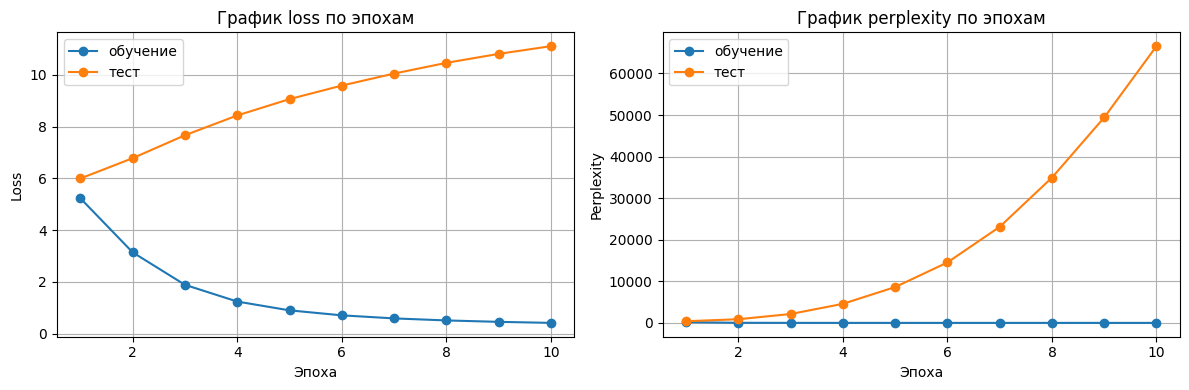

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(range(1, len(train_losses) + 1), train_losses, marker="o", label="обучение")
axes[0].plot(range(1, len(test_losses) + 1), test_losses, marker="o", label="тест")
axes[0].set_xlabel("Эпоха")
axes[0].set_ylabel("Loss")
axes[0].set_title("График loss по эпохам")
axes[0].grid(True)
axes[0].legend()

axes[1].plot(range(1, len(train_ppls) + 1), train_ppls, marker="o", label="обучение")
axes[1].plot(range(1, len(test_ppls) + 1), test_ppls, marker="o", label="тест")
axes[1].set_xlabel("Эпоха")
axes[1].set_ylabel("Perplexity")
axes[1].set_title("График perplexity по эпохам")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

###6) Функции для генерации текста

In [40]:
def decode_ids(id_list):
    return " ".join(itos[i] for i in id_list)

In [41]:
def sample_from_logits(logits, method="greedy", temperature=1.0, top_k=None):
    logits = logits.detach().cpu()
    if method == "greedy":
        return int(torch.argmax(logits).item())
    logits = logits / temperature
    if top_k is not None:
        values, indices = torch.topk(logits, k=min(top_k, logits.shape[0]))
        probs = torch.softmax(values, dim=0)
        chosen = torch.multinomial(probs, num_samples=1).item()
        return int(indices[chosen].item())
    probs = torch.softmax(logits, dim=0)
    return int(torch.multinomial(probs, num_samples=1).item())

In [42]:
@torch.no_grad()
def generate_text(model, prompt, max_new_tokens=30, method="greedy", temperature=1.0, top_k=None):
    model.eval()
    prompt_tokens = re.findall(r"\w+|[^\w\s]", prompt.lower(), re.UNICODE)
    if len(prompt_tokens) == 0:
        raise ValueError("Пустой запрос после токенизации.")
    input_ids = [stoi.get(tok, UNK_ID) for tok in prompt_tokens]
    generated = input_ids[:]
    x = torch.tensor([generated], dtype=torch.long, device=device)
    logits, h = model(x)
    next_logits = logits[0, -1]
    for _ in range(max_new_tokens):
        next_id = sample_from_logits(next_logits, method=method, temperature=temperature, top_k=top_k)
        generated.append(next_id)
        x_next = torch.tensor([[next_id]], dtype=torch.long, device=device)
        logits, h = model(x_next, h)
        next_logits = logits[0, -1]
    return decode_ids(generated)

### 7) Генерация текста разными методами

In [46]:
prompt = "тихий дон"

print("Метод: greedy")
print(generate_text(model, prompt, max_new_tokens=40, method="greedy"))

Метод: greedy
тихий дон всемирно известен в году роман был удостоен государственной премии первой степени а в его автор получил нобелевскую премию едва ли какое либо другое произведение советской литературы может соперничать с тихим доном по числу исследований и критических работ с момента появления


In [47]:
print("Метод: sampling")
print(generate_text(model, prompt, max_new_tokens=40, method="sampling"))

Метод: sampling
тихий дон молодыми вдовами цветет наш батюшка тихий дон всемирно известен в году роман был удостоен государственной премии первой степени а в его автор получил нобелевскую премию едва ли какое либо другое произведение советской литературы может соперничать с тихим доном по числу


In [48]:
print("Метод: sampling with temperature=0.5")
print(generate_text(model, prompt, max_new_tokens=40, method="sampling", temperature=0.5))

Метод: sampling with temperature=0.5
тихий дон мутнехонек течешь ах как мне тихому дону не мутну течи со дна меня тиха дона студены ключи бьют посередь меня тиха дона бела рыбица мутит старинные казачьи песни эпос и трагедия в романе шолохова тихий дон всемирно известен в году


In [49]:
print("Метод: sampling with top_k=10")
print(generate_text(model, prompt, max_new_tokens=40, method="sampling", top_k=10))

Метод: sampling with top_k=10
тихий дон ой что на полях лет войны восстание на дону было <unk> <unk> из армии <unk> и свою <unk> в сенцы на пороге <unk> и чужой ну <unk> <unk> по <unk> пошли у ворот <unk> <unk> <unk> на <unk> пантелей прокофьевич


### 8)Сравнение RNN и LSTM

In [44]:
class WordLSTM(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim)
        self.lstm = nn.LSTM(emb_dim, hidden_dim, batch_first=True)
        self.out = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, h0=None, c0=None):
        x = self.emb(x)
        if h0 is None:
            out, (hn, cn) = self.lstm(x)
        else:
            out, (hn, cn) = self.lstm(x, (h0, c0))
        logits = self.out(out)
        return logits, (hn, cn)

In [50]:
model_lstm = WordLSTM(VOCAB_SIZE, EMB_DIM, HIDDEN_DIM).to(device)
optimizer_lstm = torch.optim.Adam(model_lstm.parameters(), lr=1e-3)

In [51]:
train_losses_lstm = []
test_losses_lstm = []
train_ppls_lstm = []
test_ppls_lstm = []

In [52]:
for epoch in range(EPOCHS):
    model_lstm.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        optimizer_lstm.zero_grad()
        logits, _ = model_lstm(xb)
        loss = criterion(logits.reshape(-1, VOCAB_SIZE), yb.reshape(-1))
        loss.backward()
        optimizer_lstm.step()
        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_ppl = math.exp(train_loss)
    test_loss, test_ppl = evaluate(model_lstm, test_loader, criterion, device, VOCAB_SIZE)

    train_losses_lstm.append(train_loss)
    test_losses_lstm.append(test_loss)
    train_ppls_lstm.append(train_ppl)
    test_ppls_lstm.append(test_ppl)

    print(
        f"Эпоха {epoch+1}/{EPOCHS} | "
        f"loss обуч = {train_loss:.4f} | ppl обуч = {train_ppl:.2f} | "
        f"loss тест = {test_loss:.4f} | ppl тест = {test_ppl:.2f}"
    )

Эпоха 1/10 | loss обуч = 5.6110 | ppl обуч = 273.42 | loss тест = 5.9360 | ppl тест = 378.41
Эпоха 2/10 | loss обуч = 4.3573 | ppl обуч = 78.05 | loss тест = 6.2481 | ppl тест = 517.02
Эпоха 3/10 | loss обуч = 3.3757 | ppl обуч = 29.24 | loss тест = 6.7531 | ppl тест = 856.69
Эпоха 4/10 | loss обуч = 2.7365 | ppl обуч = 15.43 | loss тест = 7.2719 | ppl тест = 1439.31
Эпоха 5/10 | loss обуч = 2.2724 | ppl обуч = 9.70 | loss тест = 7.7971 | ppl тест = 2433.62
Эпоха 6/10 | loss обуч = 1.8982 | ppl обуч = 6.67 | loss тест = 8.3306 | ppl тест = 4148.92
Эпоха 7/10 | loss обуч = 1.5924 | ppl обуч = 4.92 | loss тест = 8.8533 | ppl тест = 6997.72
Эпоха 8/10 | loss обуч = 1.3447 | ppl обуч = 3.84 | loss тест = 9.3737 | ppl тест = 11774.96
Эпоха 9/10 | loss обуч = 1.1431 | ppl обуч = 3.14 | loss тест = 9.8803 | ppl тест = 19542.21
Эпоха 10/10 | loss обуч = 0.9771 | ppl обуч = 2.66 | loss тест = 10.3715 | ppl тест = 31935.75


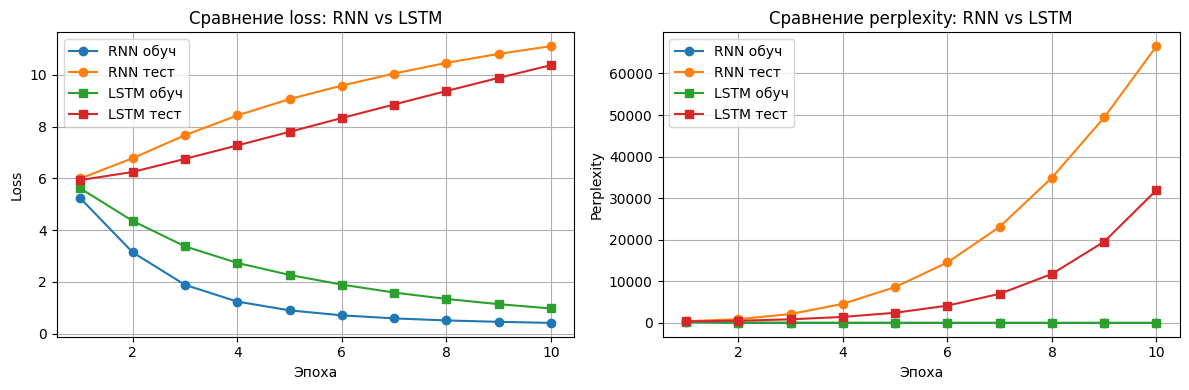

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(range(1, len(train_losses) + 1), train_losses, marker="o", label="RNN обуч")
axes[0].plot(range(1, len(test_losses) + 1), test_losses, marker="o", label="RNN тест")
axes[0].plot(range(1, len(train_losses_lstm) + 1), train_losses_lstm, marker="s", label="LSTM обуч")
axes[0].plot(range(1, len(test_losses_lstm) + 1), test_losses_lstm, marker="s", label="LSTM тест")
axes[0].set_xlabel("Эпоха")
axes[0].set_ylabel("Loss")
axes[0].set_title("Сравнение loss: RNN vs LSTM")
axes[0].grid(True)
axes[0].legend()

axes[1].plot(range(1, len(train_ppls) + 1), train_ppls, marker="o", label="RNN обуч")
axes[1].plot(range(1, len(test_ppls) + 1), test_ppls, marker="o", label="RNN тест")
axes[1].plot(range(1, len(train_ppls_lstm) + 1), train_ppls_lstm, marker="s", label="LSTM обуч")
axes[1].plot(range(1, len(test_ppls_lstm) + 1), test_ppls_lstm, marker="s", label="LSTM тест")
axes[1].set_xlabel("Эпоха")
axes[1].set_ylabel("Perplexity")
axes[1].set_title("Сравнение perplexity: RNN vs LSTM")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

*Спасибо большое, что Вы проверили мою работу. Если у Вас есть какие-либо вопросы, пожалуйста напишите через телеграм  **[@ngocleltt](https://t.me/ngocleltt)***. Рада и готова ответить!